<a href="https://colab.research.google.com/github/ecundir/Signal-Analysis-Vol-I/blob/main/Lab_1_AWGN_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#@title 1. Configuración del Entorno
import os

# Clonar el repositorio si no existe
if not os.path.exists("Signal-Analysis-Vol-I"):
    !git clone https://github.com/ecundir/Signal-Analysis-Vol-I.git

# Cambiar a la carpeta del capítulo
%cd Signal-Analysis-Vol-I/capitulo_1
print("✅ Entorno configurado correctamente.")

Cloning into 'Signal-Analysis-Vol-I'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 29 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 12.34 KiB | 12.34 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/Signal-Analysis-Vol-I/capitulo_1/Signal-Analysis-Vol-I/capitulo_1/Signal-Analysis-Vol-I/capitulo_1
✅ Entorno configurado correctamente.


Laboratorio 1.3: Análisis de Ruido Térmico (AWGN)

En este experimento, analizaremos cómo el ruido aditivo blanco gaussiano afecta la integridad de una señal digital.

    Señal: Tren de pulsos binarios.

    Canal: AWGN (Additive White Gaussian Noise).

    Objetivo: Observar la degradación de la señal al variar la relación señal-ruido (SNRdB​).

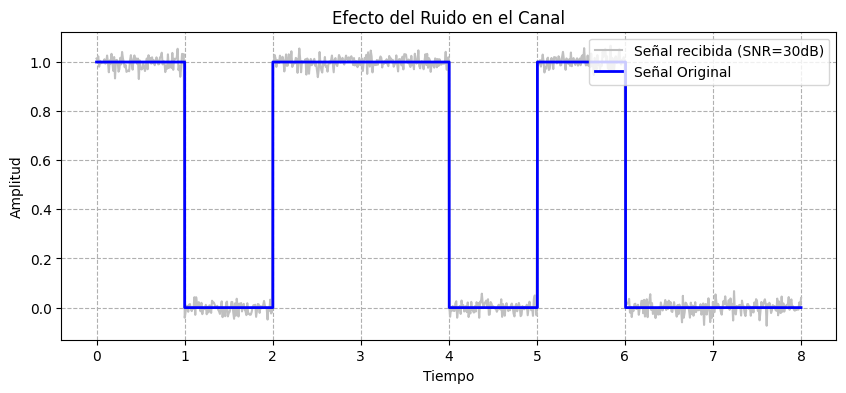

In [5]:
#@title 🎛️ Panel de Control: Experimento de Ruido Térmico { run: "auto" }
#@markdown Desliza para ajustar la intensidad del ruido.
snr_db = 30 #@param {type:"slider", min:0, max:30, step:1}
mostrar_senal_pura = True #@param {type:"boolean"}

import numpy as np
import matplotlib.pyplot as plt

# Generación de la señal base
bits = np.array([1, 0, 1, 1, 0, 1, 0, 0])
muestras_por_bit = 100
señal_pura = np.repeat(bits, muestras_por_bit)
t = np.linspace(0, len(bits), len(señal_pura))

# Cálculo del Ruido
potencia_señal = np.mean(señal_pura**2)
snr_lineal = 10**(snr_db / 10)
potencia_ruido = potencia_señal / snr_lineal
ruido = np.random.normal(0, np.sqrt(potencia_ruido), señal_pura.shape)
señal_recibida = señal_pura + ruido

# Visualización
plt.figure(figsize=(10, 4))
plt.plot(t, señal_recibida, color='silver', label=f'Señal recibida (SNR={snr_db}dB)')
if mostrar_senal_pura:
    plt.step(t, señal_pura, where='post', color='blue', linewidth=2, label='Señal Original')

plt.title("Efecto del Ruido en el Canal")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.show()